### **Agents**

Agents combine language models with tools to create systems that can reason about tasks, decide which tools to use, and iteratively work toward solutions.

`create_agent` provides a production-ready agent implementation.

An LLM agent runs tools in a loop to achieve a goal. An agent continues running until a stop condition is met, such as:
- the model emitting a final output, or
- reaching an iteration limit.

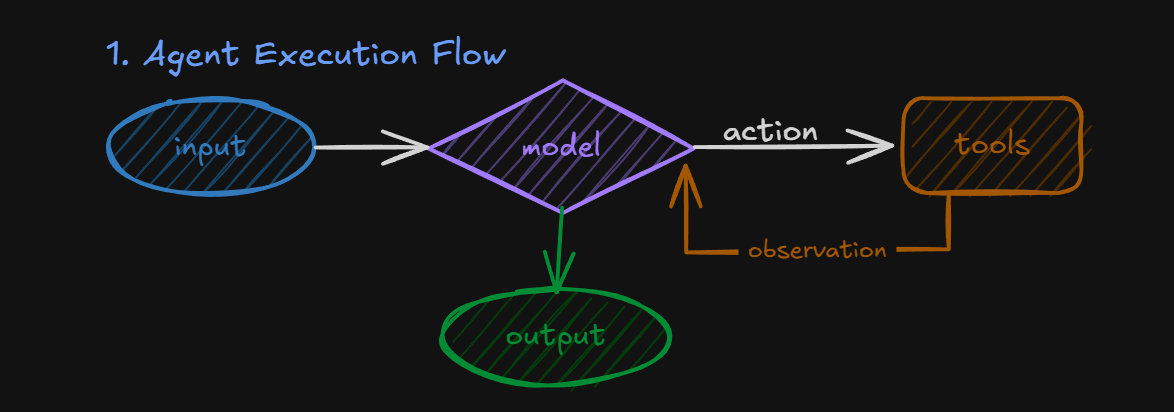

In [ ]:
print("agent")

In [ ]:
from langchain.agents import create_agent
from dotenv import load_dotenv
load_dotenv()
from langchain.chat_models import init_chat_model

# model = init_chat_model(model="moonshotai/kimi-k2-instruct-0905", model_provider="groq")

In [ ]:
from langchain_openai import ChatOpenAI
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse

basic_model = ChatOpenAI(model="gpt-4.1-mini")
advanced_model = ChatOpenAI(model="gpt-4.1")

@wrap_model_call
def dynamic_model_selection(request:ModelRequest, handler) -> ModelResponse:
    """Choose model based on conversation complexity."""
    message_count = len(request.state["messages"])
    # 1. You look at the request and decide which model to use
    if message_count > 10:
        model = advanced_model
    else:
        mode = basic_model
    # 2. You hand off the (modified) request to `handler`
    #    which actually calls the AI model and returns the response
    return handler(request.override(model=model))

In [ ]:
agent = create_agent(
    model=basic_model,  # Default model
    middleware=[dynamic_model_selection]
)

#### **Tools**
Tools give agents the ability to take actions. Agents go beyond simple model-only tool binding by facilitating:
- Multiple tool calls in sequence (triggered by a single prompt)
- Parallel tool calls when appropriate
- Dynamic tool selection based on previous results
- Tool retry logic and error handling
- State persistence across tool calls
#### **Static tools**
Static tools are defined when creating the agent and remain unchanged throughout execution. This is the most common and straightforward approach.
To define an agent with static tools, pass a list of the tools to the agent.

In [ ]:
# static tools
from langchain.tools import tool

@tool
def search(query: str) -> str:
    """Search for information."""
    return f"Results for: {query}"

@tool
def get_weather(location: str) -> str:
    """Get weather information for a location."""
    return f"Weather in {location}: Sunny, 72°F"

#### **Dynamic tools**
With dynamic tools, the set of tools available to the agent is modified at runtime rather than defined all upfront. Not every tool is appropriate for every situation. Too many tools may overwhelm the model (overload context) and increase errors; too few limit capabilities. Dynamic tool selection enables adapting the available toolset based on authentication state, user permissions, feature flags, or conversation stage.
There are two approaches depending on whether tools are known ahead of time:

When all possible tools are known at agent creation time, you can pre-register them and dynamically filter which ones are exposed to the model based on state, permissions, or context.

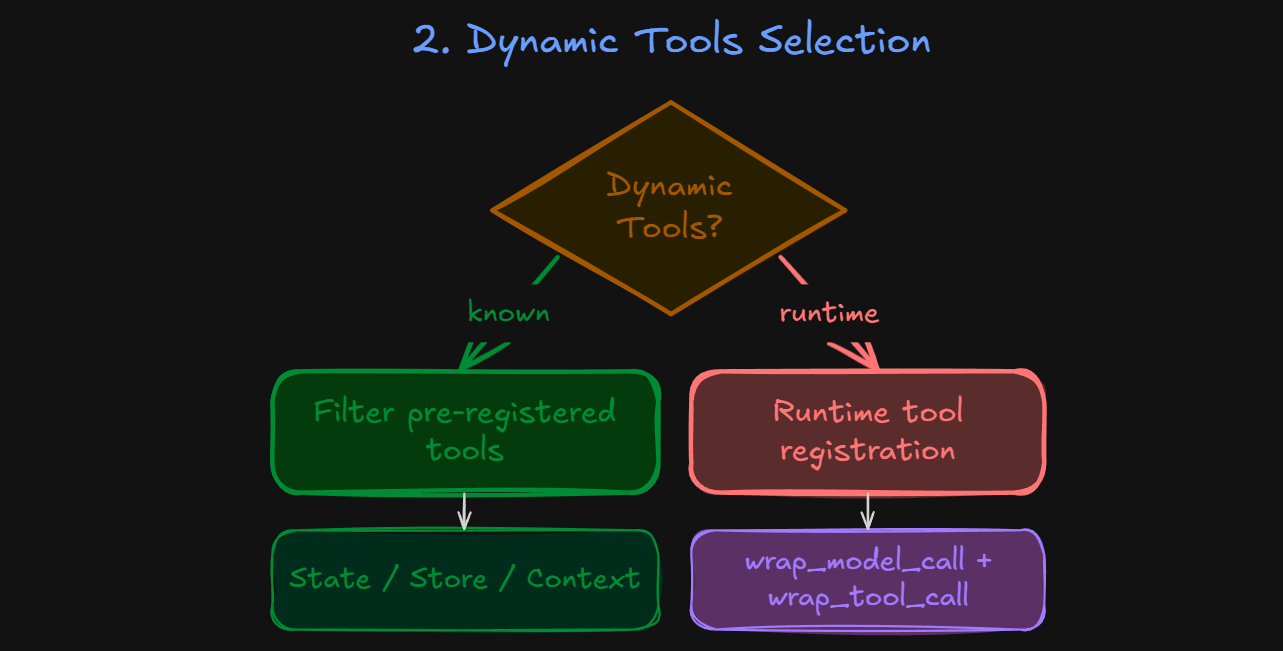

In [ ]:
from typing import Any

def get_tool_name(t: Any) -> str:
    if isinstance(t, dict):
        return str(t.get("name", ""))
    return str(getattr(t, "name", ""))

In [ ]:
# State: Enable advanced tools only after certain conversation milestones:

from langchain.agents import create_agent
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from typing import Callable

@wrap_model_call
def state_based_tools(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:
    """Filter tools based on conversation State."""
    # Read from State: check if user has authenticated
    state = request.state
    is_authenticated = state.get("authenticated", False)
    message_count = len(state["messages"])

# Only enable sensitive tools after authentication
    if not is_authenticated:
        tools = [t for t in request.tools if get_tool_name(t).startswith("public_")]
        request = request.override(tools=tools)
    elif message_count < 5:
        # Limit tools early in conversation
        tools = [t for t in request.tools if get_tool_name(t) != "advanced_search"]
        request = request.override(tools=tools)

    return handler(request)

agent = create_agent(
    model="gpt-4.1",
    # tools=[public_search, private_search, advanced_search],
    middleware=[state_based_tools]
)

In [ ]:
# Filter tools based on user preferences or feature flags in Store:

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from typing import Callable

@wrap_model_call
def state_based_tools(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:
    """Filter tools based on conversation State."""
    # Read from State: check if user has authenticated
    state = request.state
    is_authenticated = state.get("authenticated", False)
    # message_count = len(state["messages"])
    message_count = len(state.get("messages", []))

    # Only enable sensitive tools after authentication
    if not is_authenticated:
        tools = [t for t in request.tools if get_tool_name(t).startswith("public_")]
        request = request.override(tools=tools)
    elif message_count < 5:
        # Limit tools early in conversation
        tools = [t for t in request.tools if get_tool_name(t) != "advanced_search"]
        request = request.override(tools=tools)

    return handler(request)

agent = create_agent(
    model="gpt-4.1",
    # tools=[public_search, private_search, advanced_search],
    middleware=[state_based_tools]
)

In [ ]:
# Filter tools based on user permissions from Runtime Context:

In [ ]:
from dataclasses import dataclass
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse
from typing import Callable, Any, cast

@dataclass
class Context:
    user_role: str

@wrap_model_call
def context_based_tools(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse]
) -> ModelResponse:
    """Filter tools based on Runtime Context permissions."""
    # Read from Runtime Context: get user role
    if request.runtime is None or request.runtime.context is None:
        # If no context provided, default to viewer (most restrictive)
        user_role = "viewer"
    else:
        user_role = request.runtime.context.user_role

    if user_role == "admin":
        # Admins get all tools
        pass
    elif user_role == "editor":
        # Editors can't delete
        tools = [t for t in request.tools if get_tool_name(t) != "delete_data"]
        request = request.override(tools=tools)
    else:
        # Viewers get read-only tools
        tools = [t for t in request.tools if get_tool_name(t).startswith("read_")]
        request = request.override(tools=tools)

    return handler(request)

agent = create_agent(
    model="gpt-4.1",
    # tools=[read_data, write_data, delete_data],
    middleware=[cast(Any, context_based_tools)],
    context_schema=Context
)

#### **Runtime tool registration**

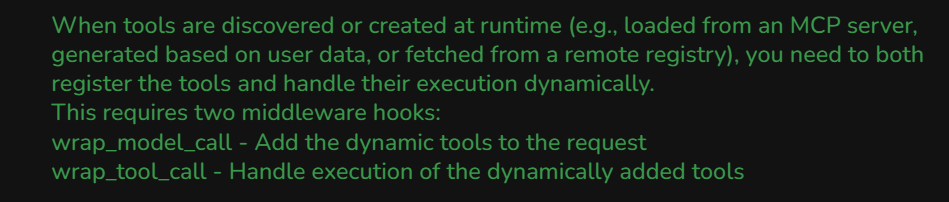

In [ ]:
from langchain.tools import tool
from langchain.agents.middleware import AgentMiddleware, ModelRequest, ToolCallRequest

# A tool that will be added dynamically at runtime
@tool
def calculate_tip(bill_amout: float, tip_percentage: float = 20.0) -> str:
    """Calculate the tip amount for bill"""
    tip = bill_amout*(tip_percentage/100)
    return f"Tip: ${tip:.2f}, Total: ${bill_amout + tip:.2f}"


class DynamicToolMiddleware(AgentMiddleware):
    """Middleware that registers and handles dynamic tools."""

    def wrap_model_Call(self, request:ModelRequest, handler):
        # Add dynamic tool to the request
        # This could be loaded from an MCP server, database, etc.
        updated = request.override(tools=[*request.tools, calculate_tip])
        return handler(updated)
    
    def wrap_tool_call(self, request: ToolCallRequest, handler):
        # Handle execution of the dynamic tool
        if request.tool_call["name"] == "calcalculate_tip":
            return handler(request.override(tool=calculate_tip))
        return handler(request)


agent = create_agent(
    model="gpt-4o",
    tools=[get_weather],  # Only static tools registered here
    middleware=[DynamicToolMiddleware()]
)

# The agent can now use both get_weather AND calculate_tip
result = agent.invoke({
    "messages": [{"role": "user", "content": "Calculate a 20% tip on $85"}]
})

In [ ]:
result["messages"][-1].content

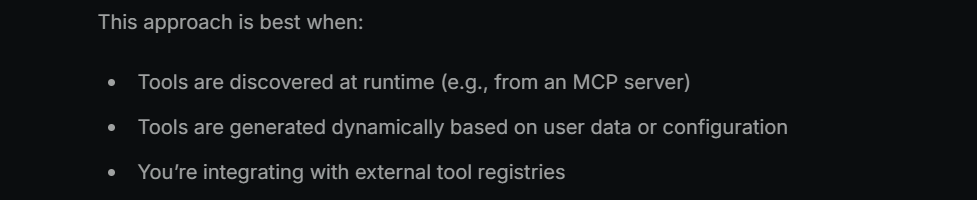

Tool error handling : To customize how tool errors are handled, use the @wrap_tool_call decorator to create middleware:

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_tool_call
from langchain.messages import ToolMessage

@wrap_tool_call
def handle_tool_errors(request, handler):
    """Handle tool execution errors with custom messages."""
    try:
        return handler(request)
    except Exception as e:
        # Return a custom error message to the model
        return ToolMessage(
            content=f"Tool error: Please check your input and try again. {str(e)}",
            tool_call_id=request.tool_call["id"]
        )

agent = create_agent(
    model="gpt-4.1",
    tools=[search, get_weather],
    middleware=[handle_tool_errors]
)

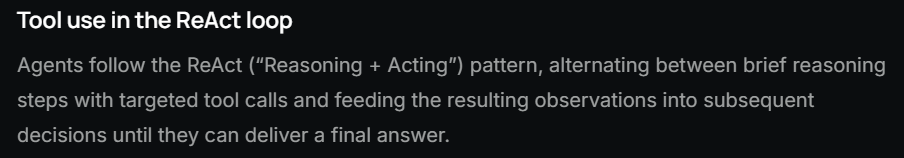

In [ ]:
from langchain.agents import create_agent
from langchain.messages import SystemMessage, HumanMessage
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
load_dotenv()

model = init_chat_model(model="moonshotai/kimi-k2-instruct-0905", model_provider="groq")

literary_agent = create_agent(
    model=model,
    system_prompt=SystemMessage(
        content=[
            {
                "type": "text",
                "text": "You are an AI assistant tasked with analyzing literary works.",
            },
            {
                "type": "text",
                "text": "<the entire contents of 'Pride and Prejudice'>",
                "cache_control": {"type": "ephemeral"}
            }
        ]
    )
)

result = literary_agent.invoke(
    {"messages": [HumanMessage("Analyze the major themes in 'Pride and Prejudice'.")]}
)

In [ ]:
result['messages'][-1].content

In [2]:
from typing import TypedDict, Any, cast
from dotenv import load_dotenv
load_dotenv()
from langchain.agents import create_agent
from langchain.agents.middleware import dynamic_prompt, ModelRequest
from langchain_tavily import TavilySearch


class Context(TypedDict):
    user_role: str

@dynamic_prompt
def user_role_prompt(request: ModelRequest) -> str:
    """Generate system prompt based on user role."""
    user_role = request.runtime.context.get("user_role", "user") if request.runtime and request.runtime.context else "user"
    base_prompt = "You are a helpful assistant."

    if user_role == "expert":
        return f"{base_prompt} Provide detailed technical responses."
    elif user_role == "beginner":
        return f"{base_prompt} Explain concepts simply and avoid jargon."

    return base_prompt


web_search = TavilySearch(
    max_results=4,              # usually 3-6 is good
    include_answer=True,        # optional: includes AI-generated answer/summary
    include_raw_content=False,  # optional: adds full page text (can be large)
    include_images=False,       # optional
)

agent = create_agent(
    model="gpt-4.1",
    tools=[web_search],
    middleware=[cast(Any, user_role_prompt)],
    context_schema=Context
)

# The system prompt will be set dynamically based on context
result = agent.invoke(
    {"messages": [{"role": "user", "content": "Explain machine learning"}]},
    context={"user_role": "expert"}
)

In [3]:
result['messages'][-1].content

'Machine learning (ML) is a branch of artificial intelligence (AI) focused on building systems that can learn from data, identify patterns, and make decisions with minimal human intervention. Here’s a breakdown of what machine learning involves:\n\n## 1. Core Idea\nMachine learning allows computers to automatically improve their performance on a task by learning from experience (data) rather than being explicitly programmed to perform that task.\n\n## 2. How It Works\n- **Data Collection**: Gather relevant data (numbers, images, text, etc.) related to the task.\n- **Model Building**: Choose or design an algorithm (a model) that will learn from this data.\n- **Training**: Feed the data to the model so it can learn patterns and relationships. This often involves adjusting internal parameters to reduce error.\n- **Testing/Evaluation**: Use new, unseen data to evaluate how well the model performs.\n- **Prediction/Inference**: Deploy the trained model to make predictions or decisions on rea